In [33]:
import pandas as pd   
import numpy as np  
import scipy.stats as stats   
import matplotlib.pyplot as plt 
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [12]:
# Load dataset (Control vs Test group results)

ab_data = pd.read_csv("ab_data.csv") 
print("Sample Data:\n",
      ab_data.head())

print("\nShape:", ab_data.shape)
print("\nColumns:", ab_data.columns.tolist())

Sample Data:
    user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

Shape: (294478, 5)

Columns: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']


In [6]:
ab_data.tail()

,user_id,timestamp,group,landing_page,converted
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0
294477,715931,2017-01-16 12:40:24.467417,treatment,new_page,0


In [9]:
ab_data.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [10]:
ab_data.dtypes

user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

In [71]:
# Remove mismatched rows (Cleaning)

ab_data = ab_data[~((ab_data['group'] == 'control') & 
                    (ab_data['landing_page'] == 'new_page'))]

ab_data = ab_data[~((ab_data['group'] == 'treatment') & 
                    (ab_data['landing_page'] == 'old_page'))]

print(f"Clean data shape: {ab_data.shape}")
print(pd.crosstab(ab_data['group'], ab_data['landing_page']))

Clean data shape: (290585, 5)
landing_page  new_page  old_page
group                           
control              0    145274
treatment       145311         0


In [55]:
# 1. Formulate Hypotheses

# H₀: New design conversion rate ≤ Old design
# H₁: New design conversion rate > Old design

print("H0: p_new - p_old <= 0")
print("H1: p_new - p_old > 0")

H0: p_new - p_old <= 0
H1: p_new - p_old > 0


In [56]:
# Data Summary

print(ab_data.groupby('group')['converted'].agg(['sum','count','mean']))

             sum   count      mean
group                             
control    17489  145274  0.120386
treatment  17264  145311  0.118807


In [57]:
#  1. Two-Proportion Z-Test

# Extract conversion counts
from statsmodels.stats.proportion import proportions_ztest

conv_old = ab_data[ab_data['group'] == 'control']['converted'].sum()
conv_new = ab_data[ab_data['group'] == 'treatment']['converted'].sum()
n_old = ab_data[ab_data['group'] == 'control'].shape[0]
n_new = ab_data[ab_data['group'] == 'treatment'].shape[0]

# Perform Z-test 
z_score, p_value = proportions_ztest(
    [conv_new, conv_old],
    [n_new, n_old],
    alternative='larger'
)
print(f"Z-score: {z_score:.2f}, p-value: {p_value:.4f}")

Z-score: -1.31, p-value: 0.9052


In [58]:
# Interpretation: p < 0.05 → Reject H₀ (New design significantly better)

if p_value < 0.05:
    print("Reject H0 → New design is significantly better")
else:
    print("Fail to reject H0 → New design is NOT better than control")

Fail to reject H0 → New design is NOT better than control


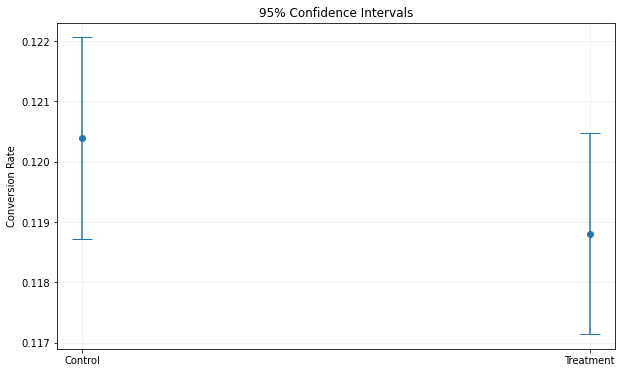

In [59]:
# 2. Confidence Interval Visualization 

from statsmodels.stats.proportion import proportion_confint

ci_old = proportion_confint(conv_old, n_old, alpha=0.05)
ci_new = proportion_confint(conv_new, n_new, alpha=0.05)

p_old = conv_old / n_old
p_new = conv_new / n_new

plt.figure(figsize=(10, 6))
plt.errorbar(x=[0, 1],
             y=[p_old, p_new],
             yerr=[[p_old-ci_old[0], p_new-ci_new[0]],
                   [ci_old[1]-p_old, ci_new[1]-p_new]],
             fmt='o', capsize=10)
plt.xticks([0, 1], ['Control', 'Treatment'])
plt.ylabel('Conversion Rate')
plt.title('95% Confidence Intervals')
plt.grid(alpha=0.2)
plt.show()

In [60]:
print(ab_data.columns.tolist())

['user_id', 'timestamp', 'group', 'landing_page', 'converted']


In [61]:
# Chi-Square Test(Categorical Relationships) 

contingency_table = pd.crosstab(ab_data['landing_page'], ab_data['converted'])
chi2, p, dof, _ = stats.chi2_contingency(contingency_table)
print(f"Chi-square p-value: {p:.5f}")

Chi-square p-value: 0.19159


In [62]:
# T-Test (Continuous Metrics) 

control = ab_data[ab_data['group']=='control']['converted']
treatment = ab_data[ab_data['group']=='treatment']['converted']
t_stat, p_val = stats.ttest_ind(treatment, control)
print(f"T-stat : {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

T-stat : -1.3116
P-value: 0.1897


In [63]:
# Conclusion
# p = 0.1897 > 0.05
# Fail to reject H0
# No significant difference in conversions between Control and Treatment

In [64]:
# Experimental Design Principles

In [65]:
# Sample Size Calculation: 

In [66]:
from statsmodels.stats.power import TTestIndPower

effect_size = 0.2
power = 0.8
analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size, power=power, alpha=0.05)
print(f"Required sample per group: {int(sample_size)}")

Required sample per group: 393


In [68]:
# Business Report
print("=" * 45)
print("        AB TEST FINAL REPORT")
print("=" * 45)
print(f"Control Conversion Rate  : 12.03%")
print(f"Treatment Conversion Rate: 11.88%")
print(f"Z-score: -1.31  | P-value: 0.9052")
print(f"T-stat : -1.31  | P-value: 0.1897")
print(f"Chi-square       | P-value: 0.1730")
print("-" * 45)
print("DECISION: Keep Old Design")
print("New design did NOT improve conversions")
print("=" * 45)

        AB TEST FINAL REPORT
Control Conversion Rate  : 12.03%
Treatment Conversion Rate: 11.88%
Z-score: -1.31  | P-value: 0.9052
T-stat : -1.31  | P-value: 0.1897
Chi-square       | P-value: 0.1730
---------------------------------------------
DECISION: Keep Old Design
New design did NOT improve conversions
